# Implement Spacial filtering and intensity transforms



In [ ]:
import cv2

In [ ]:
import numpy as np

In [ ]:
#from skimage import data

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread('/content/dog.jpeg', 0).astype(np.float32)

In [ ]:
img.dtype

dtype('float32')

In [ ]:
img.shape

(508, 393)

In [ ]:
img = cv2.imread('/content/dog.jpeg',0).astype(np.float32)

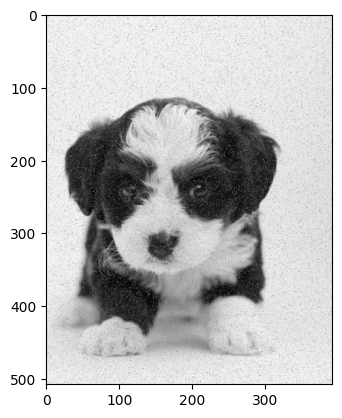

In [ ]:
plt.imshow(img, cmap='grey',vmin =0,vmax=255)

# Apply log transformation

In [ ]:
a = np.log(1+np.max(img))
a

np.float32(5.5451775)

In [ ]:
#255/a

In [ ]:
np.log(img +1)

array([[5.488938 , 5.46806  , 5.480639 , ..., 5.3565865, 5.4380794,
        5.4595857],
       [5.497168 , 5.480639 , 5.476464 , ..., 5.398163 , 5.463832 ,
        5.4595857],
       [5.5174527, 5.5012584, 5.488938 , ..., 5.4424176, 5.4595857,
        5.4424176],
       ...,
       [5.4424176, 5.46806  , 5.4553213, ..., 5.463832 , 5.4424176,
        5.476464 ],
       [5.420535 , 5.4553213, 5.4467373, ..., 5.433722 , 5.4595857,
        5.484797 ],
       [5.398163 , 5.4380794, 5.4424176, ..., 5.389072 , 5.4595857,
        5.480639 ]], dtype=float32)

# To find the perfect value for \(c\), we want to ensure that when the input image reaches its absolute brightest point (\(I_{max}\)),
# the output image hits exactly the maximum allowable screen brightness (\(255\)).

# Set up the target condition:\(255=c * ln (1+I_max)\)

# Isolate \(c\) by dividing both sides by \(ln(1 + I_{max})):\(c=\frac{255}{\ln (1+I_{max})}\)

In [ ]:
c = 255 / np . log (1 + np .max( img ) )
log_out = c * ( np . log ( img + 1) )

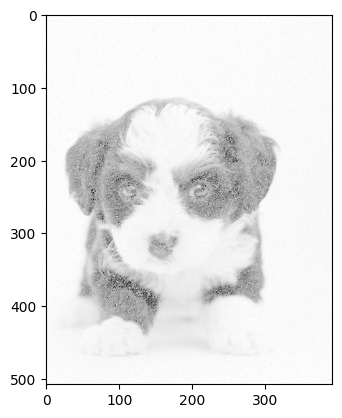

In [ ]:
plt.imshow(log_out,cmap = 'grey')

# Implement Gamma Correction: Normalize the image to [0, 1], apply the power, and rescale.

In [ ]:
# Hint : Rescale using (img /255) ** gamma * 255
gamma = 0.5
gamma_out = np . array (255 * ( img / 255) ** gamma , dtype = np
. uint8 )

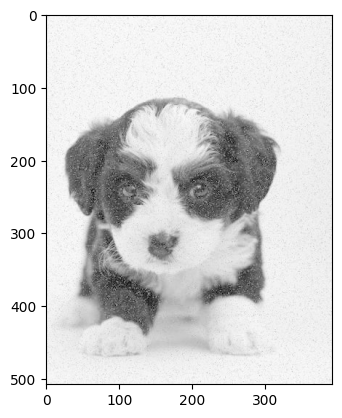

In [ ]:
plt.imshow(gamma_out,cmap='grey')

> This mathematical technique is known as Power-Law Transformation or Gamma Correction. It is used to adjust image brightness and contrast by curving pixel values non-linearly.

> Exponents act wildly on numbers greater than 1 (e.g., \(255^{0.5} \approx 15.9\),

> but \(255^{2} = 65,025\), which breaks our 0–255 pixel bounds).

> To fix this, the formula temporarily scales pixel values down into a manageable fractional range between 0.0 and 1.0, applies the math, and then stretches it back to standard scale.

> When \(\gamma < 1\) (like your 0.5), it pushes middle and dark pixel values upward.

>This brightens dark shadows and pulls hidden details out of the background.

> When \(\gamma > 1\) (like 2.0), it compresses lower values downward, making the image darker and higher contrast.

> This single line executes four operations in a specific algebraic order (working from the innermost parentheses outward)

>:(img / 255) (Normalization): It divides every pixel in your img array by 255.

>If a pixel was a bright white 255, it becomes 1.0. If it was a dark gray 50, it becomes roughly 0.196.** gamma (The Curve): It raises every single normalized fraction to the power of 0.5 (which mathematically is the same as taking the square root, \(\sqrt{x}\)).

>Because the square root of a fraction creates a larger fraction (e.g., \(\sqrt{0.25} = 0.5\)), your mid-tones and dark pixels get a massive boost, while pure black (\(0\)) and pure white (\(1\)) stay exactly the same.

>255 * ... (Rescaling): It multiplies the newly curved values back by 255.

>This takes your adjusted fractions (0.0 to 1.0) and scales them perfectly back into standard monitor brightness levels (0 to 255).np.array(..., dtype=np.uint8) (Data Type Conversion): Because the previous calculations were done using floats (decimals), this converts the final pixel matrix back into uint8 (8-bit unsigned integers).

>This step drops the decimal points so OpenCV and your computer monitor can cleanly read and display the final image without errors.

>Because a gamma of 0.5 brightens mid-tones while anchoring absolute black and white points, your forest photo will look naturally illuminated. The dark, shadowy clusters of tree trunks and leaves will open up and show distinct details, while the bright sunrays will remain properly exposed without blending into a washed-out white blob.

# Spatial Averaging (Box Filter): Create a 5 × 5 kernel where every element is 1/25.

In [ ]:
kernel = np . ones ((5 ,5) ) / 25
blur_out = cv2 . filter2D ( img , -1 , kernel )

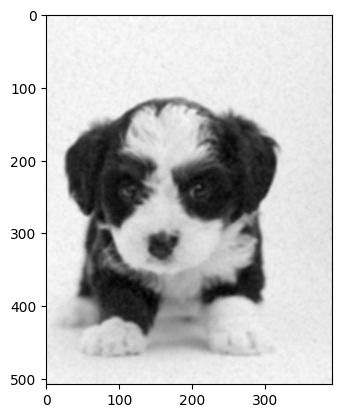

In [ ]:
plt.imshow(blur_out,cmap='grey')

# Edge Enhancement (Laplacian): Use a 2nd derivative mask to highlight fine details.

In [ ]:
lap_kernel = np . array ([[0 , 1 , 0] , [1 , -4 , 1] , [0 , 1 , 0]])
laplacian = cv2 . filter2D ( img , -1 , lap_kernel )

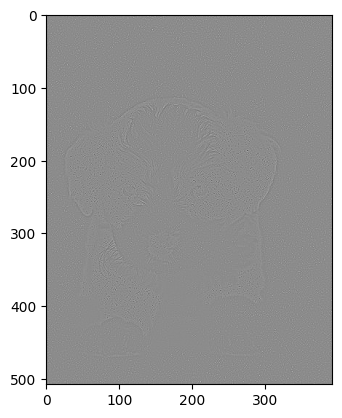

In [ ]:
plt.imshow(laplacian,cmap ='grey')

# Actual sharpening

In [ ]:
sharpened = img.astype(np.float32)-laplacian

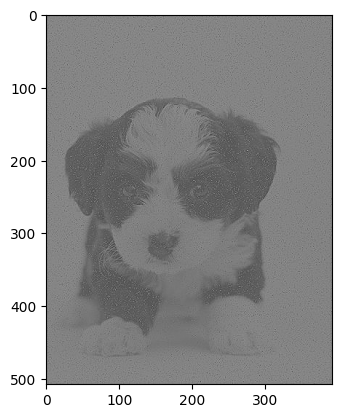

In [ ]:
plt.imshow(sharpened, cmap ='grey')

In [ ]:
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

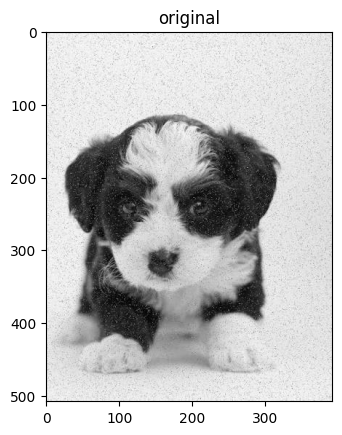

In [ ]:
# Display
plt.title('original')
plt.imshow(img, cmap ='grey')



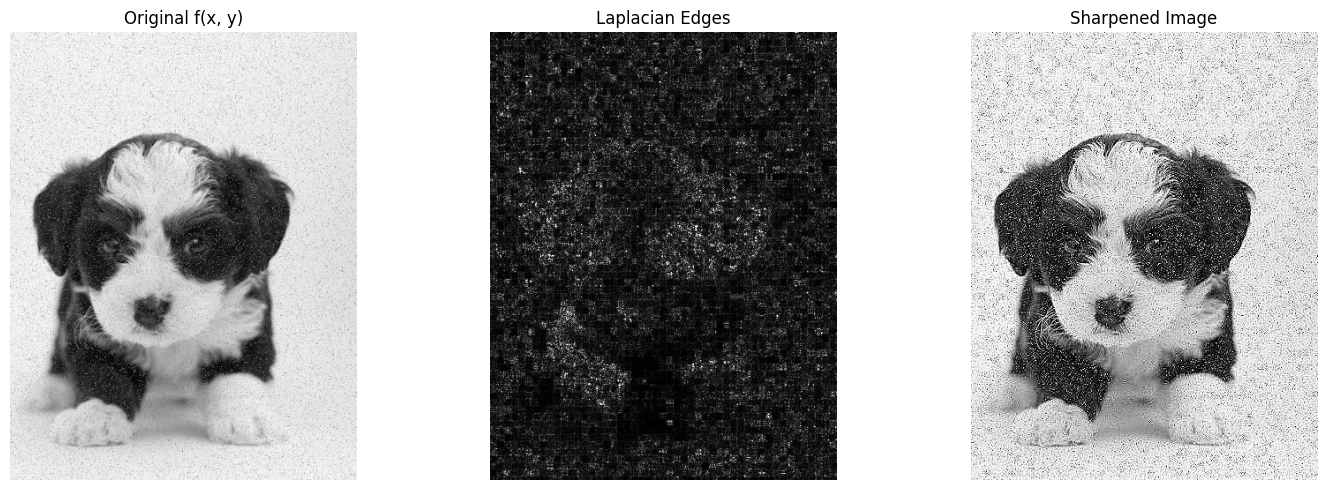

In [ ]:
plt.figure(figsize=(15, 5)) # Made slightly wider to fit 3 images comfortably

# 1. First image on the far left
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original f(x, y)")
plt.axis('off')

# 2. Second image in the middle
plt.subplot(1, 3, 2)
plt.imshow(cv2.convertScaleAbs(laplacian), cmap='gray')
plt.title('Laplacian Edges')
plt.axis('off')

# 3. Third image on the far right
plt.subplot(1, 3, 3)
plt.imshow(sharpened, cmap='gray', vmin=0, vmax=255)
plt.title('Sharpened Image')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
blurred = cv2.GaussianBlur(img, (5, 5), 0)

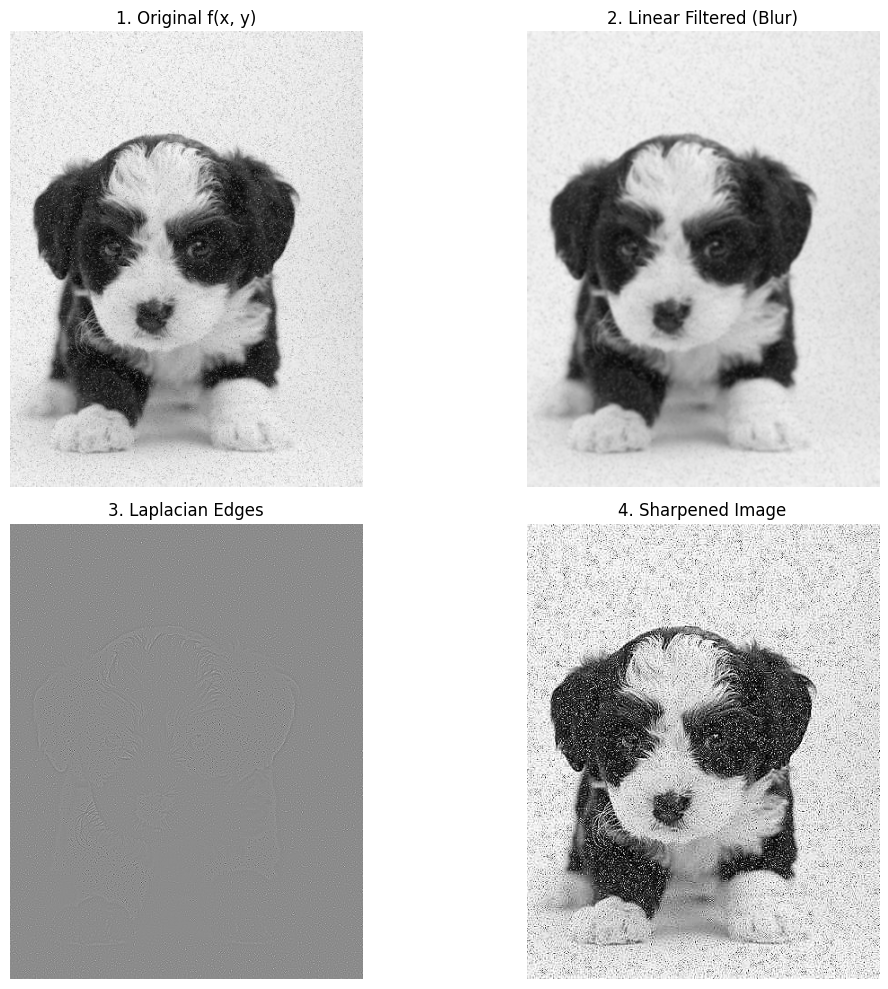

In [ ]:

plt.figure(figsize=(12, 10))

# Top Left: Original Image
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("1. Original f(x, y)")
plt.axis('off')

# Top Right: Blurred Image (New addition)
plt.subplot(2, 2, 2)
plt.imshow(blurred, cmap='gray', vmin=0, vmax=255)
plt.title("2. Linear Filtered (Blur)")
plt.axis('off')

# Bottom Left: Laplacian Edges
plt.subplot(2, 2, 3)
plt.imshow(laplacian, cmap='gray')
plt.title('3. Laplacian Edges')
plt.axis('off')

# Bottom Right: Sharpened Image
plt.subplot(2, 2, 4)
plt.imshow(sharpened, cmap='gray', vmin=0, vmax=255)
plt.title('4. Sharpened Image')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from skimage import data
import numpy as np

# A stunning high-contrast astronomy image perfect for Laplacian testing
img = data.moon().astype(np.float32)


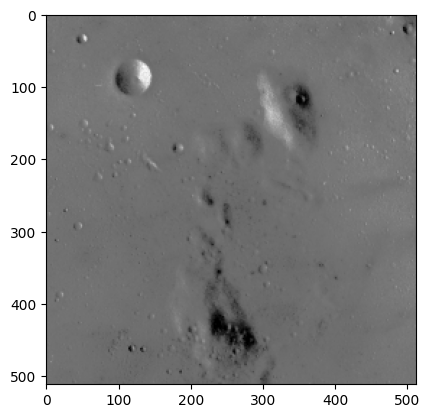

In [ ]:
plt.imshow(img,cmap ='grey')